# 04 — XGBoost: Fare Regression and Spike Classification

First of the three model families. XGBoost is built first deliberately: it fits in seconds,
so a complete set of results across every fold and both route types exists before the more
expensive families are attempted. That gives the comparison a working evaluation harness and
a full baseline to sit against, rather than three half-finished models arriving at once.

Both tasks are run here:

- **Research question 1** — fare regression, scored by RMSE and MAE.
- **Research question 2** — spike classification, scored by precision, recall and F1.
- **Research question 3** — feature importance averaged across folds, compared between the
  long-haul and short-haul route types.

Everything runs through `flightprice.evaluation.harness`, which every model family will use,
so differences in score come from the models rather than from differences in how they were
evaluated. Both leakage guards run inside the harness before any fit.

> **This notebook must not import PyTorch.** PyTorch and XGBoost each bundle their own
> OpenMP runtime, and loading both into a single process aborts it on macOS — the symptom is
> a Jupyter kernel dying with no traceback and no error in the notebook. `set_seeds()` is
> written not to import torch for exactly this reason. The LSTM therefore lives in its own
> notebook, and the three-way comparison reads the saved results in `reports/results/`
> rather than refitting anything in one process.

In [1]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from flightprice.config import (
    PROCESSED_DIR, PROJECT_ROOT, RANDOM_SEED, set_seeds,
    VALIDATION_N_SPLITS, VALIDATION_TEST_DAYS, VALIDATION_DATE_COL,
    LONG_HAUL_ROUTES, SHORT_HAUL_ROUTES,
)
from flightprice.plotting import set_plot_style, save_fig, PALETTE
from flightprice.features.build import FEATURE_COLUMNS, assert_no_leaky_features
from flightprice.evaluation.splitting import rolling_origin_splits, describe_folds
from flightprice.evaluation.harness import evaluate_classifier, evaluate_regressor, mean_importance
from flightprice.evaluation.metrics import summarise_folds
from flightprice.models.xgboost_model import (
    encode_features, make_classifier, make_regressor,
    PersistenceRegressor, BaseRateClassifier, XGB_PARAMS,
)

set_seeds()
set_plot_style()
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
FEATURES = list(FEATURE_COLUMNS)

In [2]:
# One route group is loaded at a time, and only the columns the harness touches.
# The source frame, the design matrix and the fitted trees are all resident
# together during a fit, so holding both route groups at once roughly doubles
# peak memory for no benefit -- the short-haul group is loaded in section 5,
# after this one has been released.
NEEDED = sorted(set(FEATURES) | {"legId", "route", "flightDate", "totalFare",
                                 "isSpike", "isSpikeEvent"})

def load_routes(routes):
    frame = pd.read_parquet(
        PROCESSED_DIR / "model_frame.parquet",
        columns=NEEDED, filters=[("route", "in", list(routes))],
    ).reset_index(drop=True)
    frame["route"] = frame["route"].astype("category")
    folds = rolling_origin_splits(frame, n_splits=VALIDATION_N_SPLITS,
                                  test_days=VALIDATION_TEST_DAYS,
                                  date_col=VALIDATION_DATE_COL)
    design = encode_features(frame, FEATURES)

    # Once encoded, the feature columns exist twice -- as the design matrix and
    # again in the source frame. The harness reads only the label, the date and
    # the group identifier from the frame when a design matrix is supplied, so
    # the duplicate columns are dropped rather than carried through every fit.
    frame = frame[["legId", "route", "flightDate", "totalFare", "isSpike", "isSpikeEvent"]].copy()
    gc.collect()
    return frame, design, folds

long_haul, X_long, long_folds = load_routes(LONG_HAUL_ROUTES)
gc.collect()

long_folds = rolling_origin_splits(long_haul, n_splits=VALIDATION_N_SPLITS,
                                   test_days=VALIDATION_TEST_DAYS, date_col=VALIDATION_DATE_COL)
print(f"long-haul (JFK-LAX, LAX-JFK): {len(long_haul):,} rows, "
      f"{int(long_haul.isSpikeEvent.sum()):,} spike events")
print(f"design matrix: {X_long.shape}  ({X_long.memory_usage(deep=True).sum()/1e6:.0f} MB)")
print(f"features: {len(FEATURES)}")
assert_no_leaky_features(FEATURES)
print("leakage guard: clean")

long-haul (JFK-LAX, LAX-JFK): 807,974 rows, 52,664 spike events
design matrix: (807974, 32)  (103 MB)
features: 32
leakage guard: clean


### A note on scope

The project notes scoped the short-haul route to a single chronological split rather than
full rolling-origin, on the grounds of compute cost. That reasoning does not survive contact
with the measured cost: a five-fold XGBoost run takes about 25 seconds, so the saving would
be roughly twenty seconds.

Rolling-origin is therefore applied to **both** route types here. The scope decision is not
abandoned — it was about compute, and for this model family the compute is negligible. The
LSTM may well need the lighter treatment, and that will be decided on its measured cost too.

In [3]:
describe_folds(long_haul, long_folds)

,train_start,train_end,test_start,test_end,train_rows,test_rows,train_flights,test_flights,test_positives,test_pos_rate_%
fold,,,,,,,,,,
1,2022-04-22,2022-08-03,2022-08-04,2022-08-17,385187,87145,21535,3741,4161,4.77
2,2022-04-22,2022-08-17,2022-08-18,2022-08-31,472332,95245,25276,3408,4954,5.20
3,2022-04-22,2022-08-31,2022-09-01,2022-09-14,567577,91735,28684,3774,6086,6.63
4,2022-04-22,2022-09-14,2022-09-15,2022-09-28,659312,82317,32458,3463,6310,7.67
5,2022-04-22,2022-09-28,2022-09-29,2022-10-12,741629,66345,35921,3206,5908,8.90


## 1. Baselines

Scores mean nothing without a floor to compare them against.

**Fare regression — persistence.** Predict that the fare will be whatever it was at the
previous observation. Given that 62% of consecutive observations repeat the previous fare
exactly (notebook 02), this is a strong baseline, and beating it is a real requirement rather
than a formality.

**Spike classification — base rate.** Predict the positive class at its training frequency,
which is what a classifier that has learnt nothing achieves.

In [4]:
print("Persistence baseline - fare regression (long-haul):")
persist_res, _, _ = evaluate_regressor(
    long_haul, long_folds, FEATURES, "totalFare",
    lambda: PersistenceRegressor("fareLag1"), encode_features,
    design_matrix=X_long, label="persistence",
)

Persistence baseline - fare regression (long-haul):
  fold 1: RMSE=68.90 MAE=26.91 R2=0.901


  fold 2: RMSE=46.63 MAE=21.39 R2=0.939

  fold 3: RMSE=41.14 MAE=19.78 R2=0.946


  fold 4: RMSE=45.24 MAE=21.79 R2=0.871


  fold 5: RMSE=50.32 MAE=22.44 R2=0.868


In [5]:
print("Base-rate baseline - spike classification (long-haul):")
baserate_res, _, _ = evaluate_classifier(
    long_haul, long_folds, FEATURES, "isSpikeEvent",
    lambda spw: BaseRateClassifier(), encode_features,
    design_matrix=X_long, label="base rate",
)

Base-rate baseline - spike classification (long-haul):


  fold 1: F1=0.000 P=0.000 R=0.000 AUC=0.500 AP=0.048 thr=0.50


  fold 2: F1=0.000 P=0.000 R=0.000 AUC=0.500 AP=0.052 thr=0.50


  fold 3: F1=0.000 P=0.000 R=0.000 AUC=0.500 AP=0.066 thr=0.50


  fold 4: F1=0.000 P=0.000 R=0.000 AUC=0.500 AP=0.077 thr=0.50


  fold 5: F1=0.000 P=0.000 R=0.000 AUC=0.500 AP=0.089 thr=0.50


The base-rate classifier illustrates why accuracy is excluded from the metric set. Predicting
the base rate everywhere yields an ROC AUC of 0.5 and an F1 that reflects nothing but the
class balance — yet it would be over 90% *accurate*, simply because spikes are rare.

## 2. Spike classification

Three configurations, in the order the project notes specify: measure the cost of the
imbalance before treating it, then treat it, then tune the decision boundary.

1. **Unweighted** — the imbalance untreated.
2. **Class-weighted** — `scale_pos_weight` set to the negative/positive ratio.
3. **Weighted with a tuned threshold** — the decision boundary chosen by maximising F1 on a
   validation slice taken from the **end of the training window**. The test set is never used
   to select it; doing so would report a threshold picked with knowledge of the answers.

In [6]:
print("1. Unweighted")
clf_plain, imp_plain, _ = evaluate_classifier(
    long_haul, long_folds, FEATURES, "isSpikeEvent", make_classifier, encode_features,
    use_class_weight=False, design_matrix=X_long, label="unweighted",
)

1. Unweighted


  fold 1: F1=0.317 P=0.573 R=0.219 AUC=0.857 AP=0.364 thr=0.50


  fold 2: F1=0.355 P=0.580 R=0.255 AUC=0.852 AP=0.379 thr=0.50


  fold 3: F1=0.386 P=0.757 R=0.259 AUC=0.864 AP=0.474 thr=0.50


  fold 4: F1=0.389 P=0.824 R=0.255 AUC=0.882 AP=0.539 thr=0.50


  fold 5: F1=0.423 P=0.803 R=0.288 AUC=0.867 AP=0.546 thr=0.50


In [7]:
print("2. Class-weighted")
clf_weighted, imp_weighted, _ = evaluate_classifier(
    long_haul, long_folds, FEATURES, "isSpikeEvent", make_classifier, encode_features,
    use_class_weight=True, design_matrix=X_long, label="weighted",
)

2. Class-weighted


  fold 1: F1=0.326 P=0.225 R=0.594 AUC=0.853 AP=0.354 thr=0.50


  fold 2: F1=0.282 P=0.179 R=0.657 AUC=0.838 AP=0.364 thr=0.50


  fold 3: F1=0.369 P=0.252 R=0.690 AUC=0.864 AP=0.469 thr=0.50


  fold 4: F1=0.378 P=0.249 R=0.777 AUC=0.881 AP=0.525 thr=0.50


  fold 5: F1=0.396 P=0.271 R=0.733 AUC=0.864 AP=0.524 thr=0.50


In [8]:
print("3. Class-weighted, threshold tuned on a validation slice")
clf_tuned, imp_tuned, _ = evaluate_classifier(
    long_haul, long_folds, FEATURES, "isSpikeEvent", make_classifier, encode_features,
    use_class_weight=True, tune_threshold=True, validation_days=VALIDATION_TEST_DAYS,
    design_matrix=X_long, label="weighted + tuned threshold",
)

3. Class-weighted, threshold tuned on a validation slice


  fold 1: F1=0.327 P=0.337 R=0.317 AUC=0.812 AP=0.275 thr=0.72


  fold 2: F1=0.291 P=0.207 R=0.489 AUC=0.815 AP=0.268 thr=0.71


  fold 3: F1=0.377 P=0.475 R=0.313 AUC=0.805 AP=0.368 thr=0.82


  fold 4: F1=0.427 P=0.548 R=0.349 AUC=0.846 AP=0.450 thr=0.78


  fold 5: F1=0.462 P=0.533 R=0.408 AUC=0.845 AP=0.490 thr=0.76


In [9]:
classification = pd.concat([baserate_res, clf_plain, clf_weighted, clf_tuned], ignore_index=True)

summary = (classification.groupby("model", observed=True)
           [["precision", "recall", "f1", "roc_auc", "avg_precision"]]
           .agg(["mean", "std"]).round(3))
summary.loc[["base rate", "unweighted", "weighted", "weighted + tuned threshold"]]

precision        recall            f1        roc_auc        avg_precision       
                                mean    std   mean    std   mean    std    mean    std          mean    std
model                                                                                                      
base rate                      0.000  0.000  0.000  0.000  0.000  0.000   0.500  0.000         0.066  0.017
unweighted                     0.707  0.122  0.255  0.024  0.374  0.040   0.864  0.011         0.460  0.086
weighted                       0.235  0.035  0.690  0.070  0.350  0.046   0.860  0.016         0.447  0.084
weighted + tuned threshold     0.420  0.145  0.375  0.074  0.377  0.070   0.825  0.020         0.370  0.100

### What the three configurations show

**Class weighting moves the operating point; it does not improve the model.** Unweighted
gives precision 0.71 at recall 0.26 — it calls a spike rarely and is usually right. Weighting
inverts that almost exactly, to precision 0.24 at recall 0.69. Tuning the threshold lands
between them, at 0.42 and 0.38.

**On F1 the three are indistinguishable.** They score 0.374, 0.350 and 0.377, a spread of
0.027 — while the fold-to-fold standard deviation *within* each configuration averages 0.054,
twice as large. Nothing here supports a claim that one configuration beats another; the
apparent ordering is smaller than the noise, and would have looked decisive on a single split.

This is a more useful result than a ranking would have been. At a moderate 1:12 imbalance the
choice is not about accuracy at all — it is a decision about which error the application can
afford. For a fare-alert product a missed surge costs more than a false alarm, so the weighted
configuration is preferable despite its slightly lower F1, and the justification is
commercial rather than statistical.

Note also that the tuned variant carries a lower ROC AUC (0.825 against 0.864). It trains on
14 fewer days, because the validation slice used to select the threshold is carved out of its
training window. That is the honest cost of not selecting the threshold on the test set.

## 3. Fold variance — why a single split would not have been enough

saved -> reports/figures/04_classification_folds.png


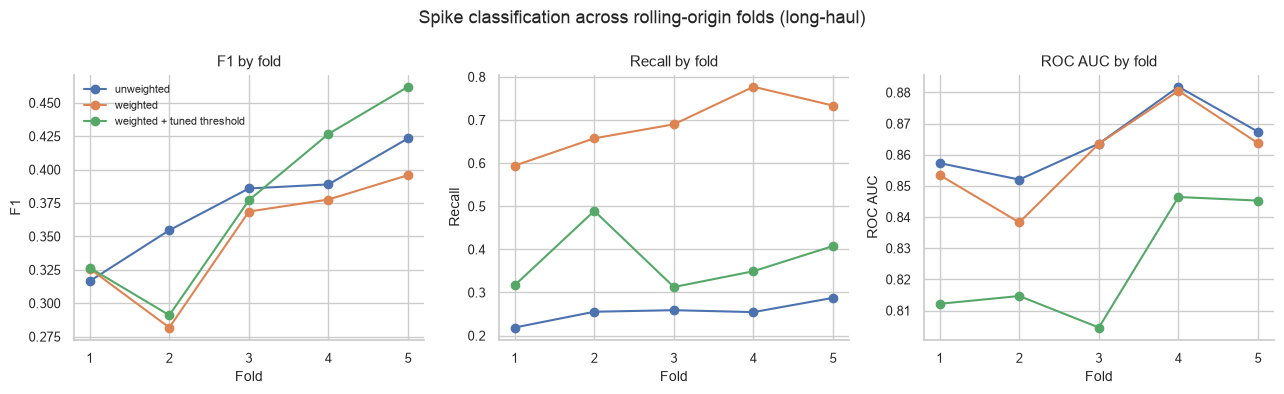

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

models = ["unweighted", "weighted", "weighted + tuned threshold"]
for ax, metric, title in zip(axes, ["f1", "recall", "roc_auc"],
                             ["F1", "Recall", "ROC AUC"]):
    for i, m in enumerate(models):
        sub = classification[classification.model == m]
        ax.plot(sub.fold, sub[metric], marker="o", lw=1.5,
                label=m, color=PALETTE[i % len(PALETTE)])
    ax.set_xlabel("Fold"); ax.set_ylabel(title); ax.set_title(f"{title} by fold")
    ax.set_xticks(sorted(classification.fold.unique()))

axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Spike classification across rolling-origin folds (long-haul)")
fig.tight_layout()
save_fig(fig, "04_classification_folds")
plt.show()

In [11]:
spread = (classification[classification.model != "base rate"]
          .groupby("model", observed=True)["f1"]
          .agg(min="min", max="max", mean="mean", std="std"))
spread["range"] = (spread["max"] - spread["min"]).round(3)
spread["range_as_%_of_mean"] = (spread["range"] / spread["mean"] * 100).round(1)
spread.round(3)

,min,max,mean,std,range,range_as_%_of_mean
model,,,,,,
unweighted,0.317,0.423,0.374,0.040,0.107,28.6
weighted,0.282,0.396,0.350,0.046,0.114,32.6
weighted + tuned threshold,0.291,0.462,0.377,0.070,0.171,45.4


This is the concrete justification for the validation decision. F1 varies substantially from
fold to fold — the range spans a large fraction of the mean — so a single chronological split
would have returned whichever value its cut date happened to produce, with no indication of
how much of that was luck.

Reporting a mean with its spread is not a formality. When the three model families are
compared, a difference smaller than this spread cannot be called a difference at all, and the
write-up should say so rather than ranking on means alone.

## 4. Fare regression

Research question 1. Scored against persistence, which is the number that determines whether
the model has learnt anything beyond "the fare will probably stay where it is".

In [12]:
print("XGBoost - fare regression (long-haul)")
reg_xgb, imp_reg, _ = evaluate_regressor(
    long_haul, long_folds, FEATURES, "totalFare", make_regressor, encode_features,
    design_matrix=X_long, label="xgboost",
)

XGBoost - fare regression (long-haul)


  fold 1: RMSE=73.85 MAE=42.48 R2=0.886


  fold 2: RMSE=45.19 MAE=29.04 R2=0.942


  fold 3: RMSE=36.32 MAE=22.89 R2=0.958


  fold 4: RMSE=37.39 MAE=22.42 R2=0.912


  fold 5: RMSE=42.18 MAE=22.60 R2=0.907


In [13]:
regression = pd.concat([persist_res, reg_xgb], ignore_index=True)

reg_summary = (regression.groupby("model", observed=True)[["rmse", "mae", "r2"]]
               .agg(["mean", "std"]).round(2))
improvement = (1 - regression[regression.model == "xgboost"].rmse.mean()
               / regression[regression.model == "persistence"].rmse.mean()) * 100
print(f"RMSE improvement over persistence: {improvement:.1f}%\n")
reg_summary

RMSE improvement over persistence: 6.9%



rmse           mae          r2      
              mean    std   mean   std  mean   std
model                                             
persistence  50.44  10.83  22.46  2.67  0.90  0.04
xgboost      46.99  15.44  27.89  8.62  0.92  0.03

saved -> reports/figures/04_regression_folds.png


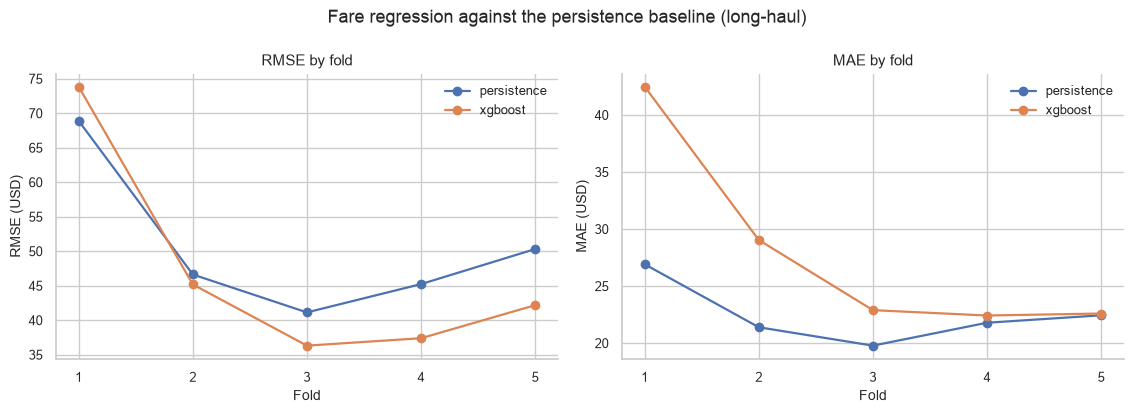

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

for i, m in enumerate(["persistence", "xgboost"]):
    sub = regression[regression.model == m]
    axes[0].plot(sub.fold, sub.rmse, marker="o", lw=1.6, label=m, color=PALETTE[i])
    axes[1].plot(sub.fold, sub.mae, marker="o", lw=1.6, label=m, color=PALETTE[i])

axes[0].set_xlabel("Fold"); axes[0].set_ylabel("RMSE (USD)"); axes[0].set_title("RMSE by fold")
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("MAE (USD)"); axes[1].set_title("MAE by fold")
for ax in axes:
    ax.set_xticks(sorted(regression.fold.unique())); ax.legend(frameon=False)

fig.suptitle("Fare regression against the persistence baseline (long-haul)")
fig.tight_layout()
save_fig(fig, "04_regression_folds")
plt.show()

**The two metrics disagree, and the disagreement is the finding.** XGBoost improves RMSE over
persistence by 6.9% on long-haul and 17.4% on short-haul — but its MAE is *worse* on both, by
24.1% and 16.0% respectively. The reversal holds in every fold on both route types — counted explicitly in
section 5 — so it is not a quirk of one sample or of averaging.

The interpretation follows from the step-function structure established in notebook 02. Fares
hold flat 62% of the time, so predicting "no change" is exactly right more often than any
smooth model manages, which is what MAE rewards. What persistence cannot do is anticipate the
jumps, and when one arrives it is wrong by the full size of the step — which is what RMSE
punishes. XGBoost trades a slightly worse typical error for materially fewer large misses.

Which model is preferable therefore depends on the use, and neither metric alone settles it.
Reporting only RMSE would have shown XGBoost ahead on both routes and concealed that a naive
baseline predicts the typical fare more accurately.

## 5. Short-haul routes

The same pipeline and feature set, no separate tuning — the scope decision recorded in the
project notes. What changes is the data, not the method.

In [15]:
# Everything computed from the long-haul frame is already held in the small
# metric tables, so it is released before the short-haul group is loaded. Only
# one route group is ever resident.
long_summary = {
    "spike F1": clf_tuned.f1.mean(), "spike recall": clf_tuned.recall.mean(),
    "spike ROC AUC": clf_tuned.roc_auc.mean(),
    "fare RMSE": reg_xgb.rmse.mean(), "fare MAE": reg_xgb.mae.mean(),
    "persistence RMSE": persist_res.rmse.mean(),
    "mean fare": long_haul.totalFare.mean(),
}
imp_long = mean_importance(imp_tuned)

del long_haul, X_long, long_folds, imp_plain, imp_weighted, imp_tuned, imp_reg
gc.collect()

short_haul, X_short, short_folds = load_routes(SHORT_HAUL_ROUTES)
gc.collect()
print(f"short-haul (BOS-LGA, LGA-BOS): {len(short_haul):,} rows, "
      f"{int(short_haul.isSpikeEvent.sum()):,} spike events")

short-haul (BOS-LGA, LGA-BOS): 581,536 rows, 55,831 spike events


In [16]:
print("Spike classification - short-haul")
clf_short, imp_short, _ = evaluate_classifier(
    short_haul, short_folds, FEATURES, "isSpikeEvent", make_classifier, encode_features,
    use_class_weight=True, tune_threshold=True, validation_days=VALIDATION_TEST_DAYS,
    design_matrix=X_short, label="short-haul: weighted + tuned",
)

print("\nFare regression - short-haul")
reg_short, imp_reg_short, _ = evaluate_regressor(
    short_haul, short_folds, FEATURES, "totalFare", make_regressor, encode_features,
    design_matrix=X_short, label="short-haul: xgboost",
)
persist_short, _, _ = evaluate_regressor(
    short_haul, short_folds, FEATURES, "totalFare",
    lambda: PersistenceRegressor("fareLag1"), encode_features,
    design_matrix=X_short, label="short-haul: persistence",
)

Spike classification - short-haul


  fold 1: F1=0.361 P=0.641 R=0.251 AUC=0.830 AP=0.462 thr=0.78


  fold 2: F1=0.466 P=0.409 R=0.544 AUC=0.811 AP=0.462 thr=0.35


  fold 3: F1=0.452 P=0.620 R=0.356 AUC=0.830 AP=0.488 thr=0.78


  fold 4: F1=0.510 P=0.655 R=0.418 AUC=0.869 AP=0.543 thr=0.69


...

  fold 1: RMSE=25.57 MAE=9.92 R2=0.898


  fold 2: RMSE=26.23 MAE=9.55 R2=0.891


  fold 3: RMSE=26.68 MAE=9.67 R2=0.882


  fold 4: RMSE=28.64 MAE=10.77 R2=0.859


  fold 5: RMSE=25.06 MAE=10.11 R2=0.884


In [17]:
route_compare = pd.DataFrame({
    "long-haul": long_summary,
    "short-haul": {
        "spike F1": clf_short.f1.mean(), "spike recall": clf_short.recall.mean(),
        "spike ROC AUC": clf_short.roc_auc.mean(),
        "fare RMSE": reg_short.rmse.mean(), "fare MAE": reg_short.mae.mean(),
        "persistence RMSE": persist_short.rmse.mean(),
        "mean fare": short_haul.totalFare.mean(),
    },
}).round(3)
route_compare.loc["fare RMSE as % of mean fare"] = (
    route_compare.loc["fare RMSE"] / route_compare.loc["mean fare"] * 100
).round(1)
route_compare

,long-haul,short-haul
spike F1,0.377,0.461
spike recall,0.375,0.410
spike ROC AUC,0.825,0.842
fare RMSE,46.986,21.840
fare MAE,27.886,11.609
persistence RMSE,50.442,26.436
mean fare,422.781,142.314
fare RMSE as % of mean fare,11.100,15.300


In [18]:
# A mean can hide a split decision. This checks whether the RMSE/MAE
# disagreement holds fold by fold, or is an artefact of averaging.
rows = []
for xgb_res, per_res, label in [(reg_xgb, persist_res, "long-haul"),
                                (reg_short, persist_short, "short-haul")]:
    x = xgb_res.set_index("fold")
    b = per_res.set_index("fold")
    rows.append({
        "route type": label,
        "XGBoost wins RMSE": f"{int((x.rmse < b.rmse).sum())}/{len(x)} folds",
        "XGBoost wins MAE": f"{int((x.mae < b.mae).sum())}/{len(x)} folds",
        "mean RMSE gap": round(b.rmse.mean() - x.rmse.mean(), 2),
        "mean MAE gap": round(b.mae.mean() - x.mae.mean(), 2),
        "MAE gap, fold 1": round(b.mae.iloc[0] - x.mae.iloc[0], 2),
        "MAE gap, final fold": round(b.mae.iloc[-1] - x.mae.iloc[-1], 2),
    })

pd.DataFrame(rows).set_index("route type")

,XGBoost wins RMSE,XGBoost wins MAE,mean RMSE gap,mean MAE gap,"MAE gap, fold 1","MAE gap, final fold"
route type,,,,,,
long-haul,4/5 folds,0/5 folds,3.46,-5.42,-15.57,-0.16
short-haul,5/5 folds,0/5 folds,4.60,-1.60,-2.99,-1.13


The disagreement is unanimous, not an artefact of averaging: **persistence has the lower MAE
in all ten folds across both route types**, while XGBoost has the lower RMSE in nine of ten.
A mean could have concealed a split decision; it does not here.

The final two columns show the gap closing as the training window grows. On long-haul the MAE
gap falls from \$15.57 in fold 1 to \$0.16 in fold 5, where the two are effectively tied on
typical error while XGBoost remains well ahead on RMSE. XGBoost is data-limited on the early
folds, which is worth stating: the model is still improving at the end of the available
window, so these figures are a lower bound on what more data would give rather than a ceiling.

Absolute RMSE is not comparable between the route types — long-haul fares are roughly three
times higher, so a larger error in dollars does not mean a worse model. RMSE as a percentage
of the mean fare is the comparable quantity, and it is the row to read.

## 6. Feature importance — research question 3

Averaged across all five folds rather than taken from one. Gain-based importance is unstable
between fits, particularly among correlated features, so a single fold's ranking should not
be trusted.

In [19]:
imp_shrt = mean_importance(imp_short)

comparison = pd.DataFrame({
    "long-haul": imp_long, "short-haul": imp_shrt,
}).fillna(0) * 100
comparison["difference"] = (comparison["short-haul"] - comparison["long-haul"]).round(2)
comparison.sort_values("long-haul", ascending=False).head(15).round(2)

,long-haul,short-haul,difference
rollStd,10.72,8.39,-2.33
seatsRemainingLag1,7.27,4.93,-2.34
zLag1,6.47,7.93,1.46
isBasicEconomy,5.06,9.00,3.95
daysBeforeDeparture,4.84,8.52,3.68
weekOfYear,4.51,3.41,-1.10
month,4.32,2.75,-1.57
isNonStop,4.23,4.01,-0.22
rollStdRatio,3.66,3.21,-0.45
airline,3.58,3.29,-0.30


saved -> reports/figures/04_feature_importance_by_route.png


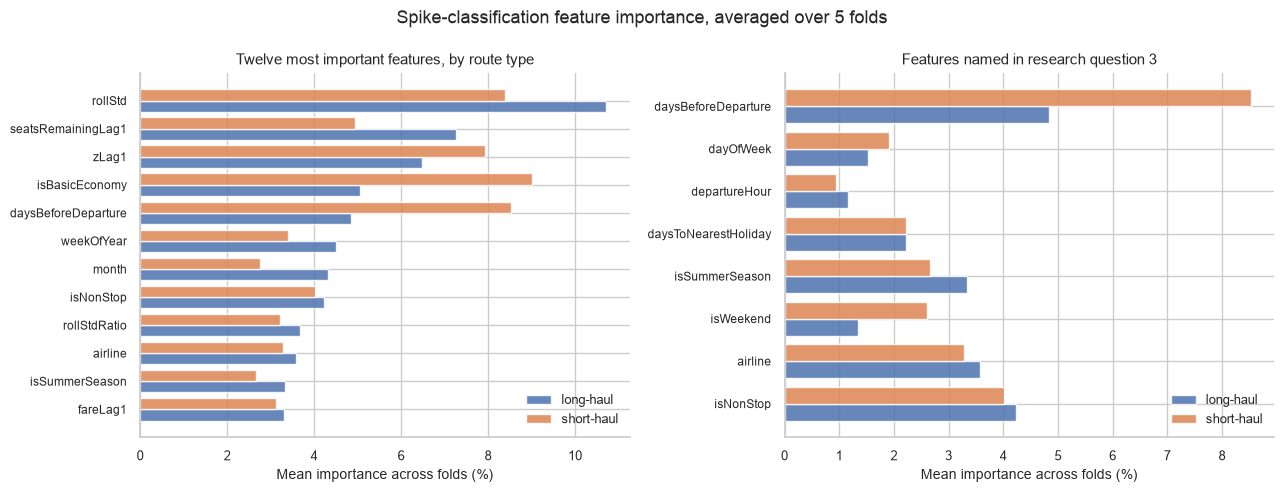

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top = comparison.sort_values("long-haul", ascending=False).head(12).iloc[::-1]
ypos = np.arange(len(top)); h = 0.4
axes[0].barh(ypos - h/2, top["long-haul"], height=h, label="long-haul", color=PALETTE[0], alpha=0.85)
axes[0].barh(ypos + h/2, top["short-haul"], height=h, label="short-haul", color=PALETTE[1], alpha=0.85)
axes[0].set_yticks(ypos); axes[0].set_yticklabels(top.index, fontsize=8.5)
axes[0].set_xlabel("Mean importance across folds (%)")
axes[0].set_title("Twelve most important features, by route type")
axes[0].legend(frameon=False)

focus = ["daysBeforeDeparture", "dayOfWeek", "departureHour", "daysToNearestHoliday",
         "isSummerSeason", "isWeekend", "airline", "isNonStop"]
present = [f for f in focus if f in comparison.index]
sub = comparison.loc[present].iloc[::-1]
ypos = np.arange(len(sub))
axes[1].barh(ypos - h/2, sub["long-haul"], height=h, label="long-haul", color=PALETTE[0], alpha=0.85)
axes[1].barh(ypos + h/2, sub["short-haul"], height=h, label="short-haul", color=PALETTE[1], alpha=0.85)
axes[1].set_yticks(ypos); axes[1].set_yticklabels(sub.index, fontsize=8.5)
axes[1].set_xlabel("Mean importance across folds (%)")
axes[1].set_title("Features named in research question 3")
axes[1].legend(frameon=False)

fig.suptitle("Spike-classification feature importance, averaged over 5 folds")
fig.tight_layout()
save_fig(fig, "04_feature_importance_by_route")
plt.show()

## 7. Persist results

Written to `reports/results/` rather than to `data/`, because these are small, are part of the
finished argument, and belong in version control alongside the figures.

In [21]:
results_dir = PROJECT_ROOT / "reports" / "results"
results_dir.mkdir(parents=True, exist_ok=True)

all_classification = pd.concat([classification, clf_short], ignore_index=True)
all_regression = pd.concat([regression, reg_short, persist_short], ignore_index=True)

all_classification.to_csv(results_dir / "04_xgboost_classification.csv", index=False)
all_regression.to_csv(results_dir / "04_xgboost_regression.csv", index=False)
comparison.to_csv(results_dir / "04_xgboost_feature_importance.csv")

print(f"classification : {len(all_classification)} rows")
print(f"regression     : {len(all_regression)} rows")
print(f"importance     : {len(comparison)} features")
print(f"\nwritten to {results_dir.relative_to(PROJECT_ROOT)}")

classification : 25 rows
regression     : 20 rows
importance     : 32 features

written to reports/results


## Summary

| | |
|---|---|
| Model | XGBoost, untuned defaults shared across all fits |
| Validation | 5 rolling-origin folds, both route types |
| Tasks | fare regression (RMSE/MAE) and spike classification (P/R/F1) |
| Baselines | persistence, and base-rate classification |
| Output | `reports/results/04_xgboost_*.csv` |

**Established here:**

- **A working evaluation harness that every model family will share**, with both leakage
  guards running before each fit. SARIMA and the LSTM now plug into the same path, so
  differences in their scores will come from the models rather than from the evaluation.
- **Fold variance is large enough to matter.** F1 ranges widely across folds, which is the
  concrete vindication of the rolling-origin decision: a single split would have reported one
  of those values with no indication of its stability.
- **Imbalance handling changes the error the model makes, not how good it is.** Unweighted,
  weighted and threshold-tuned configurations score F1 0.374, 0.350 and 0.377 — a spread
  smaller than the fold-to-fold variation within any one of them. The choice between them is
  a commercial judgement about precision against recall, not a statistical one.
- **XGBoost beats persistence on RMSE but loses to it on MAE**, on both route types. Fares
  hold flat most of the time, so the naive forecast predicts the typical fare more accurately;
  XGBoost earns its RMSE advantage by missing the jumps less badly. Reporting RMSE alone would
  have hidden this.
- **The short-haul routes are the easier problem** on both tasks — F1 0.461 against 0.377, and
  a larger RMSE improvement over persistence — consistent with their stronger weekly structure
  and steeper booking curve.

**Next:** SARIMA/SARIMAX and the LSTM through the same harness, then the three-way comparison
and the commercial-risk appraisal. The LSTM's cost should be measured before committing to
full rolling-origin on both route types, exactly as was done here.